# Оценка риска ДТП

## 1. Подключение к базе. Загрузка таблицы sql

###  1.1 Загрузка библиотек

In [1]:
!pip install -q phik
!pip install --upgrade -q scikit-learn
!pip install -q category_encoders
!pip install -q catboost
!pip install -q lightgbm
!pip install -q scikit-plot

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from phik import report
import scikitplot as skplt

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score, precision_score, recall_score
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import make_column_transformer, make_column_selector

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

###  1.2 Подключение к базе данных

In [3]:
db_config = {
'user': 'praktikum_student', # имя пользователя,
'pwd': 'Sdf4$2;d-d30pp', # пароль,
'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
'port': 6432, # порт подключения,
'db': 'data-science-vehicle-db' # название базы данных,
} 

Создадим подключение к базе данных

In [4]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

Создадим соединение

In [5]:
engine = create_engine(connection_string)

Создадим пробный запрос

In [6]:
query = '''
SELECT party_type
FROM parties;
'''
pd.read_sql_query(query, con=engine).head(5)

,party_type
0,road signs
1,road signs
2,car
3,road signs
4,road bumper


## 2. Первичное исследование таблиц

### 2.1 Проведем первичное исследование таблиц

**Проверим:**

* Все ли таблицы имеют набор данных;
* Соответствует ли количество таблиц условию задачи;
* Имеется ли общий ключ для связи таблиц.

Проверим количество таблиц в базе данных

In [7]:
query = '''
SELECT table_name
  FROM information_schema.tables
 WHERE table_schema NOT IN ('information_schema','pg_catalog');
'''
df = pd.read_sql_query(query, con=engine)
df

,table_name
0,case_ids
1,collisions
2,parties
3,vehicles


4 таблицы:

1. case_ids
2. collisions (информация о происшествиях)
3. parties (описание участников происшествия)
4. vehicles (Описание автомобиля)

Загрузим данные из таблицы **case_ids**. Проверим тип данных в таблице и количество строк.

In [8]:
query = '''
SELECT *
FROM case_ids;
'''
case_ids_data = pd.read_sql_query(query, con=engine)
case_ids_data.head()

,case_id,db_year
0,0081715,2021
1,0726202,2021
2,3858022,2021
3,3899441,2021
4,3899442,2021


In [9]:
query = '''
SELECT table_name, 
       column_name, 
       data_type 
  FROM information_schema.columns
 WHERE table_name IN ('case_ids');
'''
case_ids_data = pd.read_sql_query(query, con=engine)
case_ids_data

,table_name,column_name,data_type
0,case_ids,case_id,text
1,case_ids,db_year,text


In [10]:
query = '''
SELECT COUNT(case_id) AS total_ids,
       COUNT(DISTINCT case_id) AS unique_ids
  FROM case_ids;
'''
case_ids_data = pd.read_sql_query(query, con=engine)
case_ids_data

,total_ids,unique_ids
0,1400000,1400000


* В таблице содержаться уникальные номера (case_ids) для зарегистрированного происшествия и год происшествия (db_year).
* Тип данных text
* Всего 1400000 строк в таблице

Загрузим данные из таблицы **collisions**. Проверим тип данных в таблице и количество строк.

In [11]:
query = '''
SELECT *
FROM collisions;
'''
collisions_data = pd.read_sql_query(query, con=engine)
collisions_data.head()

,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,4083072,1942,los angeles,528.0,north,0.0,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,wet,normal,daylight,none,2009-01-22,07:25:00
1,4083075,4313,santa clara,0.0,None,1.0,clear,None,small damage,1,vehicle code violation,improper passing,hit object,fixed object,dry,normal,dark with street lights,functioning,2009-01-03,02:26:00
2,4083073,0109,alameda,0.0,None,1.0,clear,None,scratch,2,vehicle code violation,improper turning,broadside,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-11,03:32:00
3,4083077,0109,alameda,0.0,None,1.0,clear,None,scratch,2,vehicle code violation,automobile right of way,broadside,other motor vehicle,dry,normal,daylight,functioning,2009-01-11,10:35:00
4,4083087,4313,santa clara,0.0,None,1.0,clear,None,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,None,dark with street lights,functioning,2009-01-02,22:43:00


In [12]:
query = '''
SELECT table_name, 
       column_name, 
       data_type 
  FROM information_schema.columns
 WHERE table_name IN ('collisions');
'''
collisions_data = pd.read_sql_query(query, con=engine)
collisions_data

,table_name,column_name,data_type
0,collisions,party_count,integer
1,collisions,intersection,integer
2,collisions,distance,real
3,collisions,collision_date,date
4,collisions,collision_time,time without time zone
5,collisions,location_type,text
6,collisions,collision_damage,text
7,collisions,case_id,text
8,collisions,pcf_violation_category,text
9,collisions,type_of_collision,text


In [13]:
query = '''
SELECT COUNT(case_id) AS total_ids,
       COUNT(DISTINCT case_id) AS unique_ids
  FROM collisions;
'''
collisions_data = pd.read_sql_query(query, con=engine)
collisions_data

,total_ids,unique_ids
0,1400000,1400000


* В таблице содержаться 20 столбцов с различной информацией о происшествиях
* Тип данных text, time without time zone, integer
* Всего 1400000 строк в таблице

Загрузим данные из таблицы **vehicles**. Проверим тип данных в таблице и количество строк.

In [14]:
query = '''
SELECT *
FROM vehicles;
'''
vehicles_data = pd.read_sql_query(query, con=engine)
vehicles_data.head()

,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3.0
1,1,3858022,1,sedan,auto,3.0
2,1175712,5305030,1,sedan,auto,3.0
3,1175717,5305033,3,sedan,auto,5.0
4,1175722,5305034,2,sedan,auto,5.0


In [15]:
query = '''
SELECT table_name, 
       column_name, 
       data_type 
  FROM information_schema.columns
 WHERE table_name IN ('vehicles');
'''
vehicles_dataс = pd.read_sql_query(query, con=engine)
vehicles_data

,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3.0
1,1,3858022,1,sedan,auto,3.0
2,1175712,5305030,1,sedan,auto,3.0
3,1175717,5305033,3,sedan,auto,5.0
4,1175722,5305034,2,sedan,auto,5.0
...,...,...,...,...,...,...
1021229,1175684,5304990,2,sedan,manual,6.0
1021230,1175686,5304993,2,sedan,manual,3.0
1021231,1175687,5304994,2,sedan,manual,3.0
1021232,1175693,5305002,1,sedan,manual,5.0


In [16]:
query = '''
SELECT COUNT(case_id) AS total_ids,
       COUNT(DISTINCT case_id) AS unique_ids
  FROM vehicles;
'''
vehicles_data = pd.read_sql_query(query, con=engine)
vehicles_data

,total_ids,unique_ids
0,1021234,792642


* В таблице содержаться 6 столбцов с информацией об автомобилях
* Тип данных text, time without и integer
* Всего 1021234 строк в таблице. Имеет неуникальные case_id и неуникальные party_number, которые сопоставляются с таблицей collisions и таблицей parties.

Загрузим данные из таблицы **parties**. Проверим тип данных в таблице и количество строк.

In [6]:
query = '''
SELECT *
FROM parties;
'''
parties_data = pd.read_sql_query(query, con=engine).head(10)
parties_data.head()

,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use
0,22,3899454,1,road signs,1,29.0,had not been drinking,None,0.0
1,23,3899454,2,road signs,0,7.0,had not been drinking,None,0.0
2,29,3899462,2,car,0,21.0,had not been drinking,None,0.0
3,31,3899465,2,road signs,0,24.0,had not been drinking,None,0.0
4,41,3899478,2,road bumper,0,NaN,not applicable,not applicable,0.0


In [7]:
query = '''
SELECT table_name, 
       column_name, 
       data_type 
  FROM information_schema.columns
 WHERE table_name IN ('parties');
'''
parties_data = pd.read_sql_query(query, con=engine)
parties_data

,table_name,column_name,data_type
0,parties,cellphone_in_use,integer
1,parties,party_number,integer
2,parties,at_fault,integer
3,parties,insurance_premium,integer
4,parties,id,integer
5,parties,case_id,text
6,parties,party_drug_physical,text
7,parties,party_type,text
8,parties,party_sobriety,text


In [8]:
query = '''
SELECT COUNT(case_id) AS total_ids,
       COUNT(DISTINCT case_id) AS unique_ids
  FROM parties;
'''
parties_data = pd.read_sql_query(query, con=engine)
parties_data

,total_ids,unique_ids
0,2752408,1400000


* В таблице содержаться 9 столбцов с информацией об участниках происшествия
* Тип данных text и integer
* Всего 2752408 строк в таблице. Имеет неуникальный case_id, который сопоставляется с соответствующим ДТП в таблице collisions.

In [9]:
query = '''
SELECT constraint_name,
       table_name,
       column_name
  FROM information_schema.key_column_usage
'''
df = pd.read_sql_query(query, con=engine)
df

,constraint_name,table_name,column_name
0,pg_proc_oid_index,pg_proc,oid
1,pg_proc_proname_args_nsp_index,pg_proc,proname
2,pg_proc_proname_args_nsp_index,pg_proc,proargtypes
3,pg_proc_proname_args_nsp_index,pg_proc,pronamespace
4,pg_type_oid_index,pg_type,oid
...,...,...,...
162,parties_pk,parties,id
163,vehicles_pk,vehicles,id
164,collisions_case_ids_case_id_fk,collisions,case_id
165,parties_case_ids_case_id_fk,parties,case_id


Таблицы имеют общий ключ **case_id** (Уникальный номер для зарегистрированного происшествия) и могут быть объединены через него.

### 2.2 Вывод

Провели первичный анализ таблиц. 
Убедились, что все таблицы имеют набор данных и соответствуют условию задачи.
Также выяснили, что таблицы имеют общий ключ case_id (Уникальный номер для зарегистрированного происшествия), через который могут быть связаны друг с другом.

## 3. Статистический анализ факторов ДТП

### 3.1 Проведем статистический анализ факторов ДТП 

Выясним, в какие месяцы происходит наибольшее количество аварий.  
Проанализируем весь период наблюдений (таблица collisions).   

Создадим sql-запрос, сгруппируем данные по количеству происшествий и месяцам, отфильтруем полученные данные по убыванию.

In [9]:
query = '''
SELECT COUNT(case_id) AS collision_count,
       EXTRACT(MONTH from CAST(collision_date AS DATE)) AS collision_month
FROM collisions
GROUP BY EXTRACT(MONTH from CAST(collision_date AS DATE))
ORDER BY collision_count DESC;
'''
df_collision_month = pd.read_sql_query(query, con=engine)
df_collision_month

,collision_count,collision_month
0,139581,3.0
1,132044,1.0
2,130316,5.0
3,130180,4.0
4,128858,2.0
5,112237,10.0
6,107945,12.0
7,105159,9.0
8,104770,11.0
9,104089,8.0


Таким образом, видим, что наибольшее количество аварий происходит в **марте** и **январе**, а наименьшее **летом** (июнь, июль, август).

Построим график

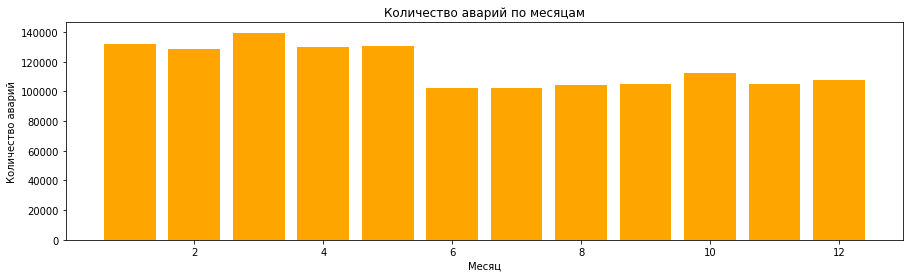

In [10]:
plt.figure(figsize=(15, 4))
plt.bar(df_collision_month['collision_month'], df_collision_month['collision_count'], color='orange')
plt.xlabel('Месяц')
plt.ylabel('Количество аварий')
plt.title('Количество аварий по месяцам')
plt.show()

* Наибольшее количество аварий обычно происходит в зимой и весной (январь, февраль, март, апрель, май).
* Летом и осенью примерно одинаковое количество аварий.

* Количество аварий имеет сезонные колебания в течение года и, возможно, связаны с разными факторами:

1. Погодные условия
Зимой и весной возможны снегопады, гололедица и дожди, которые делают дороги скользкими и ухудшают видимость. Это увеличивает вероятность ДТП из-за ухудшенных дорожных условий.

2. Условия освещения 
Зимой дни короче, что означает, что большинство автомобильных поездок происходит в условиях недостаточной освещенности или в темное время суток. Это может увеличить риск аварий.

3. Условия дорог
Весной проявляются дефекты дорог, такие как ямы или повреждения асфальта, которые могут увеличить риск ДТП.

4. Поведение водителей
Некоторые исследования показывают, что в зимние месяцы психологические факторы, такие как депрессия или усталость, могут влиять на поведение водителей, что увеличивает вероятность аварий.

5. Летом и осенью условия на дорогах обычно более благоприятные, дни длинные, погода стабильнее, видимость лучше. Это может уменьшить риск ДТП.

In [12]:
query = '''
SELECT EXTRACT(YEAR FROM collision_date) AS year,
       EXTRACT(MONTH FROM collision_date) AS month,
       COUNT(case_id) AS cases_count
FROM collisions
GROUP BY EXTRACT(YEAR FROM collision_date), EXTRACT(MONTH FROM collision_date)
'''

cases_by_months = pd.read_sql_query(query, con=engine)
cases_by_months

,year,month,cases_count
0,2009.0,1.0,35062
1,2009.0,2.0,34480
2,2009.0,3.0,36648
3,2009.0,4.0,35239
4,2009.0,5.0,36916
5,2009.0,6.0,34202
6,2009.0,7.0,35161
7,2009.0,8.0,34508
8,2009.0,9.0,35555
9,2009.0,10.0,37835


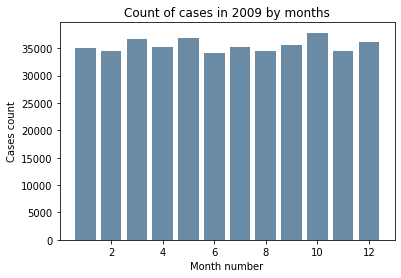

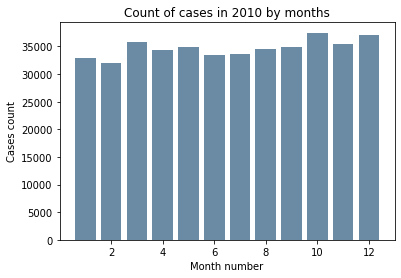

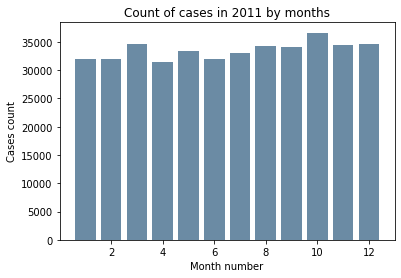

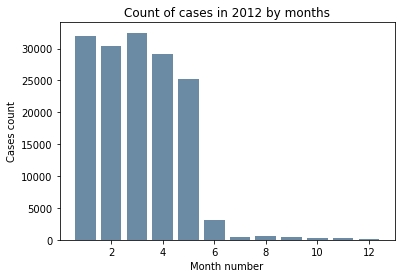

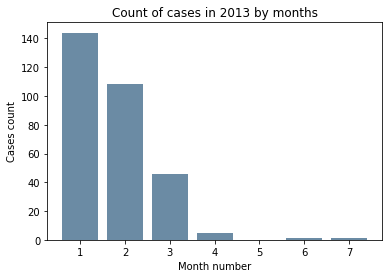

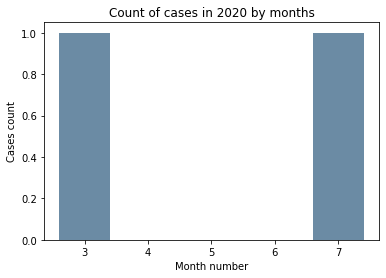

In [13]:
# Посмотрим распределение ДТП по месяцам за каждый год
for year in cases_by_months['year'].value_counts().sort_index().index:
    case = cases_by_months[cases_by_months['year'] == year]
    plt.bar(case['month'], case['cases_count'], color='xkcd:grey blue')
    plt.title(f'Count of cases in {int(year)} by months')
    plt.ylabel('Cases count')
    plt.xlabel('Month number')
    plt.show()

Видим, что полные данные в БД есть только с 2009 по 2011 гг.   
В 2012 зафиксированы ДТП за все 12 месяцев, но начиная с июня данных подозрительно мало.
Данные за 2013 и 2020 тоже представлены не в полном объеме и не по всем месяцам.

Таким образом, для анализа отберем только данные с 2009 по 2011гг включительно.

In [6]:
query = '''
SELECT COUNT(case_id) AS collision_count,
       EXTRACT(MONTH from CAST(collision_date AS DATE)) AS collision_month
FROM collisions
WHERE EXTRACT(YEAR FROM collision_date) <= 2011
GROUP BY EXTRACT(MONTH from CAST(collision_date AS DATE))
ORDER BY collision_count DESC;
'''
df_collision_month = pd.read_sql_query(query, con=engine)
df_collision_month

,collision_count,collision_month
0,111933,10.0
1,107745,12.0
2,107036,3.0
3,105148,5.0
4,104649,9.0
5,104517,11.0
6,103467,8.0
7,101835,7.0
8,101032,4.0
9,99880,1.0


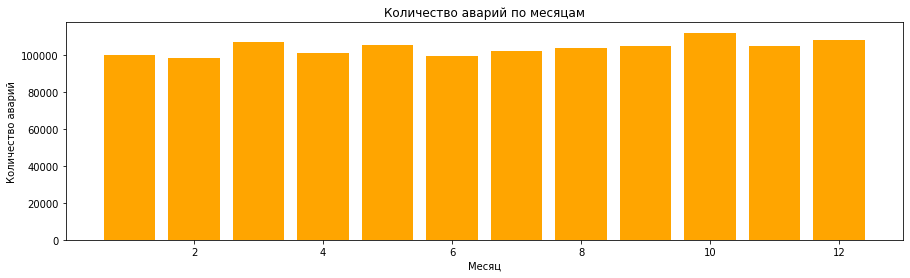

In [7]:
plt.figure(figsize=(15, 4))
plt.bar(df_collision_month['collision_month'], df_collision_month['collision_count'], color='orange')
plt.xlabel('Месяц')
plt.ylabel('Количество аварий')
plt.title('Количество аварий по месяцам')
plt.show()

Количество ДТП примерно равномерно распределены в течение всего года. Чуть больше аварий приходится на октябрь и декабрь, что может быть объяснено изменениями в погоде, что может привести к более опасным условиям для вождения и, следовательно, к большему числу ДТП. Декабрь также, например, часто ассоциируется с праздниками, такими как Рождество и Новый год, когда количество людей на дорогах увеличивается из-за праздничных поездок и вечеринок, что может привести к повышенному риску ДТП из-за увеличенного потока транспорта и возможного употребления алкоголя.

### 3.2 Аналитические задачи

Скоро состоится первое совещание рабочей группы. Чтобы обсуждение было конструктивным, каждый сотрудник должен понимать данные. Для этого нужно создать подходящие аналитические задачи и поручить их решение коллегам. 

* Нужно создать не менее 6 задач для коллег

* Прописать порядок решения для двух задач из списка. Обязательное условие — решение этих задач должно включать связь не менее 2-х таблиц.

**Примеры задач для коллег:**

1. Исследование связи между погодой и серьезностью происшествий
2. Исследование связи между состоянием дороги и серьезностью происшествий/повреждений транспортного средства
3. Анализ взаимосвязи между освещением на месте ДТП и серьезностью происшествий/тяжестью повреждений
4. Исследование основных факторов, вызывающих аварии. Какие нарушения ПДД чаще всего встречаются в случае ДТП.
5. Анализ типов столкновений, наиболее часто встречающихся в ДТП. Какие виды столкновений происходят наиболее часто.
6. Исследование влияния возраста автомобиля на серьезностью происшествий/тяжесть повреждений в ДТП
7. Анализ типов транспортных средств, наиболее часто участвующих в ДТП, и их влияния на серьезность происшествий. 
8. Исследование влияния алкогольного опьянения на тяжесть повреждений в результате ДТП.
9. Анализ влияния физического состояния участника и наличия лекарств на тяжесть повреждений. Какие факторы, такие как сонливость или принимаемые лекарства, связаны с серьезностью ДТП.
10. Исследование временной зависимости ДТП. Определить, есть ли определенные временные интервалы или дни недели, когда аварии происходят чаще всего.
11. Анализ географического распределения ДТП. Выявление наиболее опасных районов с наибольшим количеством происшествий.

**Решение некоторых задач**

**1. Исследование влияния возраста автомобиля на серьезностью происшествий/тяжесть повреждений в ДТП**

In [12]:
# Создадим sql-запрос
query = '''
SELECT v.vehicle_age, c.collision_damage
FROM vehicles AS v
JOIN collisions AS c ON v.case_id = c.case_id;
'''

df = pd.read_sql_query(query, con=engine)
df

,vehicle_age,collision_damage
0,8.0,small damage
1,11.0,scratch
2,6.0,small damage
3,3.0,small damage
4,7.0,scratch
...,...,...
1021229,3.0,small damage
1021230,4.0,small damage
1021231,4.0,small damage
1021232,4.0,small damage


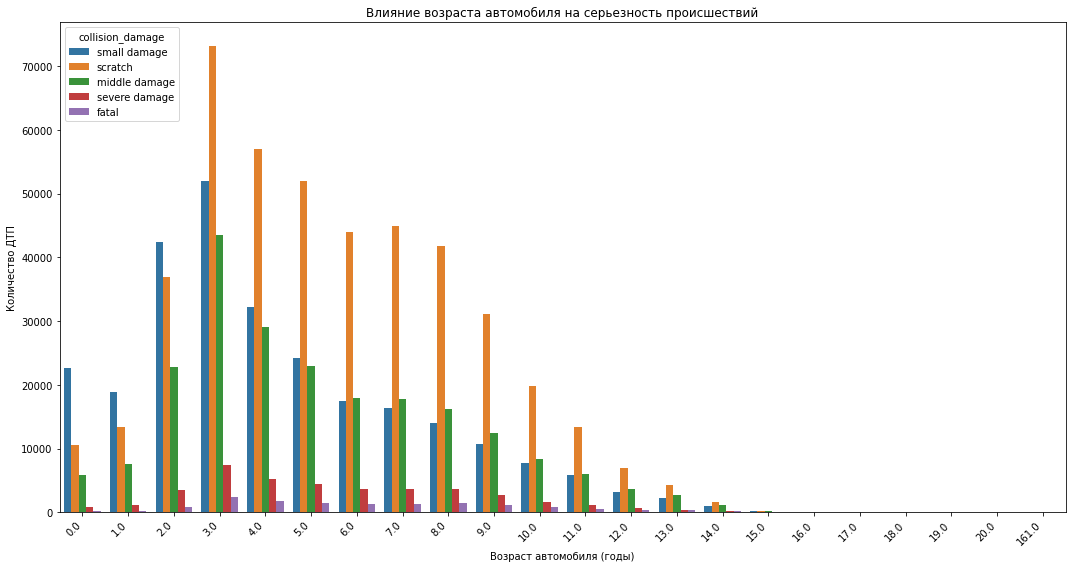

In [13]:
# Построим график

plt.figure(figsize=(15, 8))
sns.countplot(data=df, x='vehicle_age', hue='collision_damage')
plt.title('Влияние возраста автомобиля на серьезность происшествий')
plt.xlabel('Возраст автомобиля (годы)')
plt.ylabel('Количество ДТП')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

На графике видно, что новые авто (до 1 года) и старые (от 10 лет) реже всего попадают в аварии. В то время, как 3х-летние автомобили чаще всего становятся участниками различных ДТП.

Это можно объяснить тем, что водители новых автомобилей могут быть более осторожными и внимательными на дороге, так как только начинают использовать новое транспортное средство. С течением времени опыт вождения может увеличиваться, и водители могут становиться более уверенными, но при этом и более небрежными или рискованными.

Также мы видим, что с возрастом автомобилей количество ДТП уменьшается, что можно объяснить просто уменьшением количества старых машин в общем объеме и, может быть, опытностью их владельцев.

**2. Анализ влияния физического состояния участника и наличия лекарств на тяжесть повреждений**

In [14]:
query = '''
SELECT p.party_drug_physical, c.collision_damage
FROM parties AS p
JOIN collisions AS c ON p.case_id = c.case_id;
'''
df = pd.read_sql_query(query, con=engine)
df

,party_drug_physical,collision_damage
0,None,scratch
1,not applicable,small damage
2,under drug influence,fatal
3,G,middle damage
4,not applicable,small damage
...,...,...
2752403,None,small damage
2752404,None,severe damage
2752405,sleepy/fatigued,small damage
2752406,None,middle damage


**E** — Under Drug Influence (Под воздействием лекарств)  
**F** — Impairment — Physical (Ухудшение состояния)  
**G** — Impairment Unknown (Не известно)  
**H** — Not Applicable (Не оценивался)  
**I** — Sleepy/Fatigued (Сонный/Усталый)  

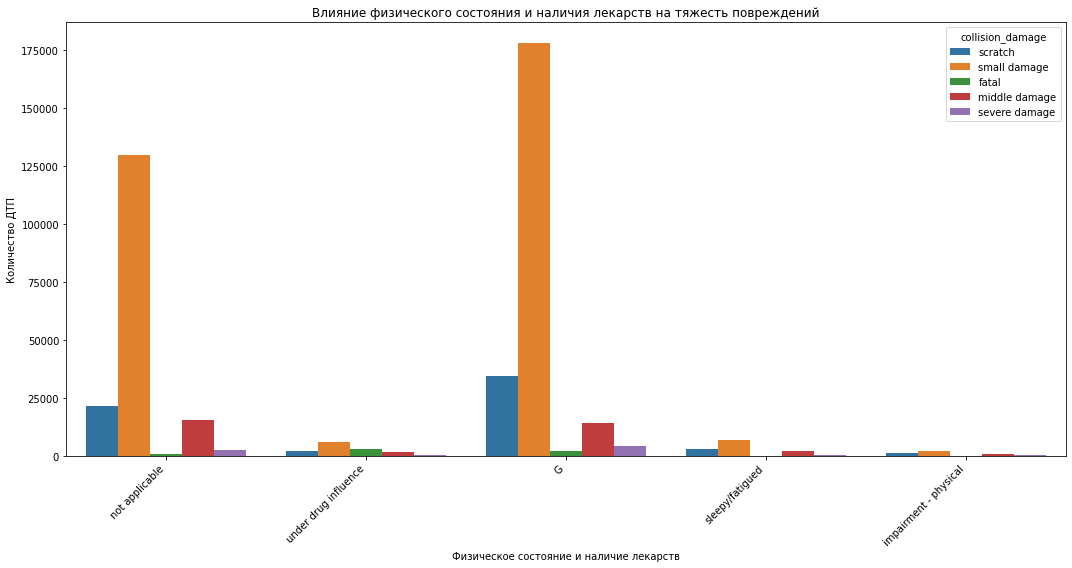

In [15]:
plt.figure(figsize=(15, 8))
sns.countplot(data=df, x='party_drug_physical', hue='collision_damage')
plt.title('Влияние физического состояния и наличия лекарств на тяжесть повреждений')
plt.xlabel('Физическое состояние и наличие лекарств')
plt.ylabel('Количество ДТП')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Для всех состояний водителя (кроме under drug influence - под воздействием лекарств) вероятность тотально разбить машину крайне мала.   
В большинстве случаев автомобили в ДТП получают небольшие повреждения (small damage) и царапины (scratch).

## 4. Создание модели для оценки водительского риска

### 4.1 Первичный отбор факторов, необходимых для модели.

Проведем первичный отбор факторов, необходимых для модели.
Изучим описание факторов. Отберем те, которые могут влиять на вероятность ДТП.

Будем рассматривать признаки в разрезе того, могут ли они влиять на виновность участника до начала движения, так как в описании задания написано, что система должна оповестить водителя до начала движения.

**Целевой признак**

* 'at_fault' - Виновность участника 0 - нет, 1 - целевой признак  


**Важные признаки**

* 'insurance_premium' - Сумма страховки. Этот признак имеет смысл, так как страховая премия может быть связана с историей вождения, типом автомобиля и другими факторами, которые могут влиять на вероятность ДТП.  

* 'party_sobriety' - Трезвость участника. Важный признак, так как состояние участника может значительно повлиять на его способности управлять автомобилем и, следовательно, на вероятность ДТП.
  
* 'party_drug_physical' - Состояние участника: физическое или с учётом принятых лекарств. Важный признак, так как состояние участника может значительно повлиять на его способности управлять автомобилем и, следовательно, на вероятность ДТП.
* 'cellphone_in_use' - Наличие телефона в автомобиле (возможности разговаривать по громкой связи). Может увеличивать риск ДТП
* 'county_city_location' - Номер географических районов, где произошло ДТП. Этот признак может быть важным, так как географическое местоположение может быть связано с особенностями дорожной инфраструктуры и плотностью транспортного потока, что влияет на вероятность ДТП.
* 'direction' - Направление движения. Местоположение может быть связано с особенностями дорожной инфраструктуры и плотностью транспортного потока, что влияет на вероятность ДТП.
* 'vehicle_type' - Тип кузова. Характеристики автомобиля могут влиять на его поведение на дороге и, следовательно, на вероятность ДТП.
* 'vehicle_transmission' - Тип КПП. Характеристики автомобиля могут влиять на его поведение на дороге и, следовательно, на вероятность ДТП.
* 'vehicle_age' - Возраст автомобиля (в годах). Характеристики автомобиля могут влиять на его поведение на дороге и, следовательно, на вероятность ДТП. Также это обязательный признак по желанию заказчика проекта
* 'weather_1' - Погода. Факторы относится к условиям дорожного движения, может существенно влиять на вероятность ДТП.
* 'location_type' - Тип дороги. Факторы относится к условиям дорожного движения, может существенно влиять на вероятность ДТП.
* 'distance' - Расстояние от главной дороги (метры). Факторы относится к условиям дорожного движения, может существенно влиять на вероятность ДТП.
* 'road_surface' - Состояние дороги. Факторы относится к условиям дорожного движения, может существенно влиять на вероятность ДТП.
* 'road_condition_1' - Дорожное состояние. Факторы относится к условиям дорожного движения, может существенно влиять на вероятность ДТП.
* 'lighting' - Освещение. Факторы относится к условиям дорожного движения, может существенно влиять на вероятность ДТП.
* 'control_device' - Работоспособность устройств управления  
* 'collision_date' - Дата происшествия. Ранее мы выяснили, что есть месяцы, такие как март, когда возрастает количество аварий. Влияет на вероятность ДТП и виновность участника
* 'collision_time' - Время происшествия. Например, в ночное время или раннее утреннее вероятность того, что водитель едет уставший и сонный, сильно выше, чем в обеденное. Влияет на вероятность ДТП и виновность участника.

**Неважные признаки:**

* 'id' - Индекс текущей таблицы, не несет важной информации, можем удалить
* 'case_id' - Идентификационный  номер в базе данных, не несет важной информации, можем удалить
* 'party_number' - Номер участника происшествия, не несет важной информации, можем удалить
* 'party_type' - Тип участника происшествия, можем удалить, тк у нас выбран только 'car'
* 'county_location' - Названия географических районов, где произошло ДТП. Этот признак может быть важным, так как географическое местоположение может быть связано с особенностями дорожной инфраструктуры и плотностью транспортного потока, что влияет на вероятность ДТП. Но мы оставим только номера районов - 'county_city_location'.
* 'party_count'- Количество участников, можем удалить, признак не подходит для построения модели, так как определяется уже после ДТП и при прогнозировании не доступен
* 'collision_damage' - Серьёзность происшествия, можем удалить, признак не подходит для построения модели, так как определяется уже после ДТП и при прогнозировании не доступен
* 'primary_collision_factor' - Основной фактор аварии, можем удалить, признак не подходит для построения модели, так как определяется уже после ДТП и при прогнозировании не доступен
* 'pcf_violation_category' - Категория нарушения, можем удалить, признак не подходит для построения модели, так как определяется уже после ДТП и при прогнозировании не доступен
* 'intersection' - Является ли место происшествие перекрёстком. Может быть связан с ДТП, так как на перекрестках часто происходят аварии. Но данные частично пересекаются с колонкой 'location_type'.
* 'type_of_collision' - Тип аварии, можем удалить, признак не подходит для построения модели, так как определяется уже после ДТП и при прогнозировании не доступен
* 'motor_vehicle_involved_with' - Дополнительные участники ДТП, можем удалить, признак не подходит для построения модели, так как определяется уже после ДТП и при прогнозировании не доступен

### 4.2 Подготовим набор данных на основе первичного предположения заказчика

* Выберем тип виновника — только машина (car).
* Возьмем случаи, когда ДТП привело к любым значимым повреждениям автомобиля любого из участников — все, кроме типа SCRATCH (царапина).
* Для моделирования возьмем данные только за 2012 год.
* Подготовим исходной таблицы должна проводиться с помощью sql-запроса.

В таблицу войдут только те признаки, которые могут влиять на вероятность ДТП.

In [16]:
query = '''
SELECT p.at_fault,
    p.cellphone_in_use,
    p.insurance_premium,
    p.party_sobriety,
    p.party_drug_physical,
    EXTRACT(MONTH FROM c.collision_date)::int AS month,
    EXTRACT(HOUR FROM c.collision_time)::int AS hour,
    c.control_device,
    c.county_city_location,
    c.lighting,
    c.location_type,
    c.road_condition_1 AS road_condition,
    c.road_surface,
    v.vehicle_age,
    v.vehicle_transmission,
    v.vehicle_type,
    c.weather_1 AS weather,
    c.direction,
    c.distance
FROM parties AS p
JOIN collisions AS c ON p.case_id = c.case_id
JOIN vehicles AS v ON p.case_id = v.case_id
WHERE p.party_type = 'car'
    AND EXTRACT(YEAR FROM c.collision_date)::int = 2012
    AND collision_damage != 'scratch';
'''

data = pd.read_sql_query(query, con=engine)
data

,at_fault,cellphone_in_use,insurance_premium,party_sobriety,party_drug_physical,month,hour,control_device,county_city_location,lighting,location_type,road_condition,road_surface,vehicle_age,vehicle_transmission,vehicle_type,weather,direction,distance
0,1,0.0,43.0,had not been drinking,None,1,17.0,none,3711,dark with street lights,None,normal,dry,12.0,manual,hatchback,clear,south,12.0
1,1,0.0,19.0,"had been drinking, under influence",under drug influence,1,2.0,functioning,3500,dark with street lights,None,loose material,dry,3.0,manual,sedan,clear,None,0.0
2,1,0.0,86.0,had not been drinking,None,1,12.0,none,3700,daylight,None,normal,dry,13.0,auto,coupe,clear,east,413.0
3,0,0.0,53.0,had not been drinking,None,1,10.0,none,1900,daylight,None,normal,dry,5.0,manual,coupe,clear,north,1079.0
4,0,0.0,53.0,had not been drinking,None,1,10.0,none,1900,daylight,None,normal,dry,3.0,manual,sedan,clear,north,1079.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118406,0,0.0,46.0,had not been drinking,None,1,9.0,none,3019,daylight,highway,normal,dry,6.0,manual,sedan,raining,north,100.0
118407,1,0.0,51.0,had not been drinking,None,1,9.0,none,3026,daylight,highway,normal,dry,14.0,manual,sedan,clear,south,1900.0
118408,0,0.0,39.0,had not been drinking,None,1,9.0,none,3026,daylight,highway,normal,dry,14.0,manual,sedan,clear,south,1900.0
118409,1,0.0,27.0,had not been drinking,None,1,15.0,none,3394,daylight,None,normal,dry,1.0,manual,sedan,clear,north,133.0


In [17]:
#Итоговые признаки, вошедшие в датасет (19 колонок)
data.columns

Index(['at_fault', 'cellphone_in_use', 'insurance_premium', 'party_sobriety',
       'party_drug_physical', 'month', 'hour', 'control_device',
       'county_city_location', 'lighting', 'location_type', 'road_condition',
       'road_surface', 'vehicle_age', 'vehicle_transmission', 'vehicle_type',
       'weather', 'direction', 'distance'],
      dtype='object')

### 4.3 Статистическое исследование отобранных факторов.

Проведем статистическое исследование отобранных факторов:

* По результату исследовательского анализа внесем корректировки
* Категоризируем исходные данные и проведем масштабирование.
* Подготовим обучающую и тестовую выборки.

Посмотрим основную информацию о признаках датасета

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118411 entries, 0 to 118410
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   at_fault              118411 non-null  int64  
 1   cellphone_in_use      107507 non-null  float64
 2   insurance_premium     113289 non-null  float64
 3   party_sobriety        116682 non-null  object 
 4   party_drug_physical   8695 non-null    object 
 5   month                 118411 non-null  int64  
 6   hour                  118283 non-null  float64
 7   control_device        117957 non-null  object 
 8   county_city_location  118411 non-null  object 
 9   lighting              118080 non-null  object 
 10  location_type         55137 non-null   object 
 11  road_condition        117843 non-null  object 
 12  road_surface          117645 non-null  object 
 13  vehicle_age           115046 non-null  float64
 14  vehicle_transmission  116545 non-null  object 
 15  

Всего в итоговый датасет попало 19 столбцов и 118411 строк


**числовые признаки**

* insurance_premium
* month
* hour
* vehicle_age  
* distance

**категориальные признаки**

* at_fault  
* party_sobriety   
* party_drug_physical  
* cellphone_in_use  
* vehicle_type  
* vehicle_transmission  
* county_city_location  
* weather 
* location_type  
* road_surface  
* road_condition  
* lighting  
* control_device 
* direction

Проверим данные на явные дубликаты

In [19]:
data.duplicated().sum()

2196

Удалим явные дубли

In [20]:
data.drop_duplicates(inplace=True, ignore_index=True)

Проверим количество пропусков в данных

In [21]:
data.isna().sum()

at_fault                     0
cellphone_in_use         10697
insurance_premium         5058
party_sobriety            1699
party_drug_physical     107630
month                        0
hour                       125
control_device             453
county_city_location         0
lighting                   324
location_type            62135
road_condition             539
road_surface               739
vehicle_age               3252
vehicle_transmission      1828
vehicle_type                 0
weather                    379
direction                28421
distance                     0
dtype: int64

Довольно много пропущенных значений и практически во всех колонках

Удалим пропущенные значения в колонках, где их меньше 1000 (это меньше 1%)

In [22]:
columns = ['hour', 'control_device', 'lighting', 'road_condition', 
           'road_surface', 'weather']

# обработка пропусков
data = data.dropna(subset=columns)

Остальные данные проверим внимательнее и решим, удалять ли пропуски или заменить на какие-то значения.

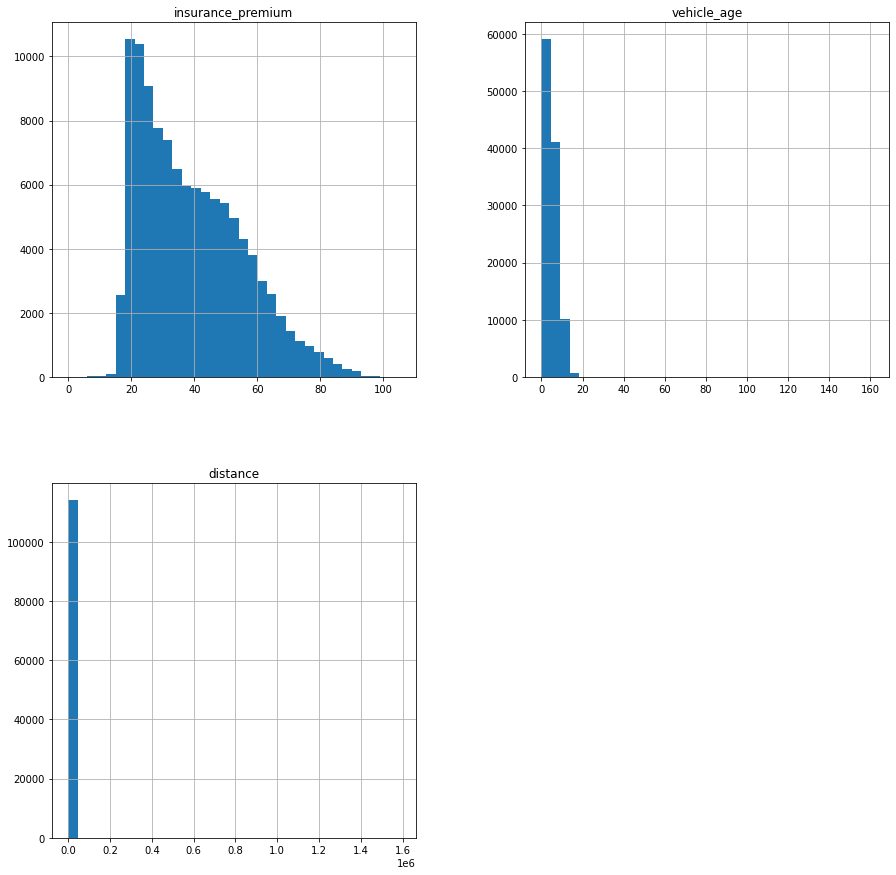

In [23]:
col = ['insurance_premium', 'vehicle_age', 'distance']

data[col].hist(bins=35, figsize=(15, 15))
plt.show()

In [24]:
data[col].describe().T

,count,mean,std,min,25%,50%,75%,max
insurance_premium,109213.0,38.664326,16.374614,0.0,25.0,36.0,50.0,105.0
vehicle_age,110981.0,4.923131,3.276011,0.0,3.0,4.0,7.0,161.0
distance,114149.0,737.589172,7022.281315,0.0,2.0,120.0,528.0,1584000.0


Наблюдаются аномальные значения в колонках vehicle_age и distance (слишком большой возраст автомобилей и слишком длинные дасстояния до главной дороги)

In [25]:
data['vehicle_age'].unique()

array([ 12.,   3.,  13.,   5.,   8.,  11.,   6.,  10.,   2.,   4.,   0.,
         1.,   9.,   7.,  nan,  16.,  14.,  15.,  17.,  19., 161.])

In [26]:
data.groupby('vehicle_age').size().reset_index(name='count').sort_values(by='vehicle_age', ascending=True)

,vehicle_age,count
0,0.0,6486
1,1.0,5486
2,2.0,12288
3,3.0,20765
4,4.0,14038
5,5.0,11367
6,6.0,8241
7,7.0,8119
8,8.0,7443
9,9.0,5922


Есть 4 автомобиля с возрастом 161 год. Это явная ошибка, опечатка в данных. Так как таких значений мало, удалим их.

In [27]:
data = data[data['vehicle_age'] != 161]

Пропуски заменим медианным значением

In [28]:
data['vehicle_age'] = data['vehicle_age'].fillna(data['vehicle_age'].median())

In [29]:
data['vehicle_age'].unique()

array([12.,  3., 13.,  5.,  8., 11.,  6., 10.,  2.,  4.,  0.,  1.,  9.,
        7., 16., 14., 15., 17., 19.])

Рассмотрим признак 'distance' (расстояние до главной дороги)

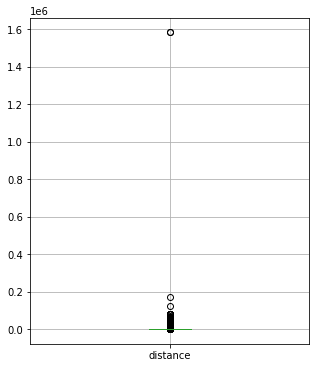

In [30]:
data['distance'].plot(kind='box',
                             figsize=(5,6),
                             grid=True,
                             legend=True,
                             title='');

Удалим выбросы (все, что больше 200000)

In [31]:
data = data[(data['distance'] <= 200000)]

Рассмотрим признак 'insurance_premium' (страховка)

In [32]:
data.groupby('insurance_premium').size().reset_index(name='count').sort_values(by='insurance_premium', 
                                                                               ascending=True)

,insurance_premium,count
0,0.0,11
1,2.0,1
2,4.0,3
3,5.0,8
4,6.0,7
...,...,...
97,99.0,3
98,100.0,2
99,101.0,3
100,102.0,1


Заменим пропуски медианным значением

In [33]:
data['insurance_premium'].fillna(data['insurance_premium'].median(), inplace=True)

Рассмотрим признак cellphone_in_use

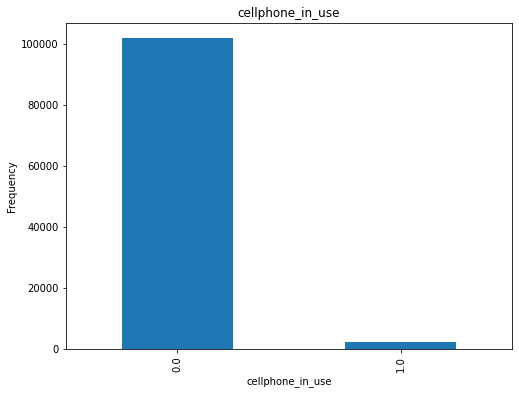

In [34]:
plt.figure(figsize=(8, 6))
data['cellphone_in_use'].value_counts().plot(kind='bar')
plt.title('cellphone_in_use')
plt.xlabel('cellphone_in_use')
plt.ylabel('Frequency')
plt.show()

Большинство значений имеет значение 0, заменим пропуски на 0

In [35]:
data['cellphone_in_use'].fillna(0, inplace=True)

Рассмотрим целевой признак at_fault (Виновность участника)

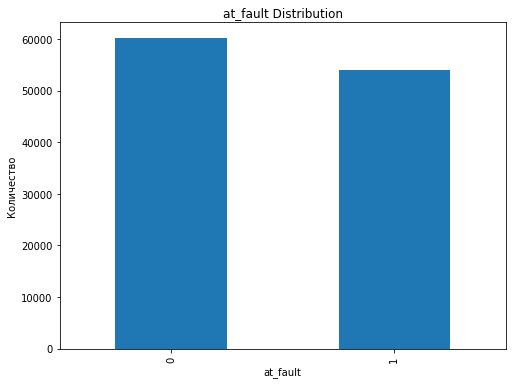

In [36]:
plt.figure(figsize=(8, 6))
data['at_fault'].value_counts().plot(kind='bar')
plt.title('at_fault Distribution')
plt.xlabel('at_fault')
plt.ylabel('Количество')
plt.show()

Все значения признака имеют вид 0 (не виновен) и 1 (виновен). Видим, что данные сбалансированы.

Рассмотрм признак 'party_sobriety' (Трезвость участника)

In [37]:
data['party_sobriety'].unique()

array(['had not been drinking', 'had been drinking, under influence',
       None, 'impairment unknown',
       'had been drinking, not under influence',
       'had been drinking, impairment unknown', 'not applicable'],
      dtype=object)

A — Had Not Been Drinking (Не пил)  
B — Had Been Drinking, Under Influence (Был пьян, под влиянием)  
C — Had Been Drinking, Not Under Influence (Был пьян, не под влиянием)  
D — Had Been Drinking, Impairment Unknown (Был пьян, ухудшение неизвестно)  
G — Impairment Unknown (Неизвестно ухудшение)  
H — Not Applicable (Не оценивался)  
— Not Stated (Не указано)

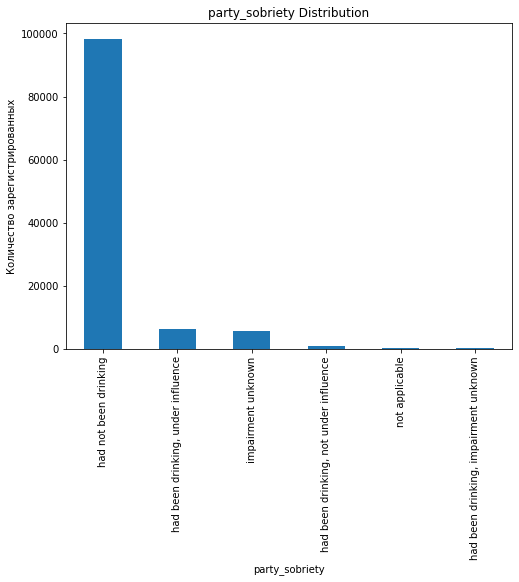

In [38]:
plt.figure(figsize=(8, 6))
data['party_sobriety'].value_counts().plot(kind='bar')
plt.title('party_sobriety Distribution')
plt.xlabel('party_sobriety')
plt.ylabel('Количество зарегистрированных')
plt.show()

In [39]:
data['party_sobriety'] = data['party_sobriety'].fillna('impairment unknown')

В большинстве случаев ДТП водители были трезвы

Рассмотрим признак 'party_drug_physical' (Состояние участника: физическое или с учётом принятых лекарств).

In [40]:
data['party_drug_physical'].unique()

array([None, 'under drug influence', 'G', 'sleepy/fatigued',
       'not applicable', 'impairment - physical'], dtype=object)

E — Under Drug Influence (Под воздействием лекарств)  
F — Impairment — Physical (Ухудшение состояния)  
G — Impairment Unknown (Не известно)  
H — Not Applicable (Не оценивался)  
I — Sleepy/Fatigued (Сонный/Усталый)  
— Not Stated (Не указано)  

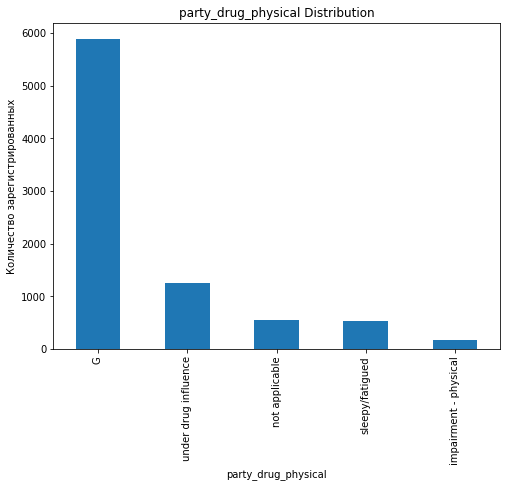

In [41]:
plt.figure(figsize=(8, 6))
data['party_drug_physical'].value_counts().plot(kind='bar')
plt.title('party_drug_physical Distribution')
plt.xlabel('party_drug_physical')
plt.ylabel('Количество зарегистрированных')
plt.show()

В большинстве случаев состояние участника ДТП неизвестно (категория G - Impairment Unknown (Не известно))

Заменим пропуски в колонках 'party_drug_physical', 'party_sobriety' на категорию G

In [42]:
data['party_drug_physical'] = data['party_drug_physical'].fillna('G')

Рассмотрим значения в колонке month (месяц, когда произошло ДТП), на этот раз у нас данные только за 2012 год

In [43]:
data['month'].unique()

array([ 1,  2,  3,  5,  6,  4,  8,  7,  9, 10, 11, 12])

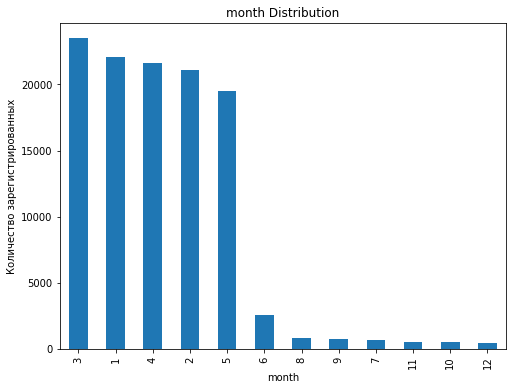

In [44]:
plt.figure(figsize=(8, 6))
data['month'].value_counts().plot(kind='bar')
plt.title('month Distribution')
plt.xlabel('month')
plt.ylabel('Количество зарегистрированных')
plt.show()

Весной и зимой - наибольшее количество ДТП

Рассмотрим значения в колонке hour (час, когда произошло ДТП)

In [45]:
data['hour'].unique()

array([17.,  2., 12., 10., 13., 18.,  4., 16., 15.,  8., 14.,  9., 22.,
       21.,  3., 11.,  6., 19., 20.,  1.,  7.,  0.,  5., 23.])

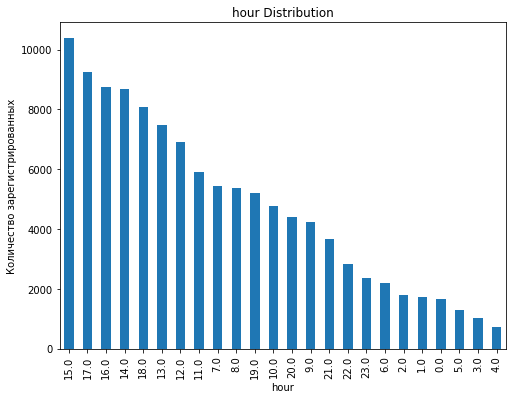

In [46]:
plt.figure(figsize=(8, 6))
data['hour'].value_counts().plot(kind='bar')
plt.title('hour Distribution')
plt.xlabel('hour')
plt.ylabel('Количество зарегистрированных')
plt.show()

Наибольшее количество аварий с 15:00 до 17:00.

Рассмотрим значения в колонке 'vehicle_type' (Тип кузова)

In [47]:
data['vehicle_type'].unique()

array(['hatchback', 'sedan', 'coupe', 'minivan', 'other'], dtype=object)

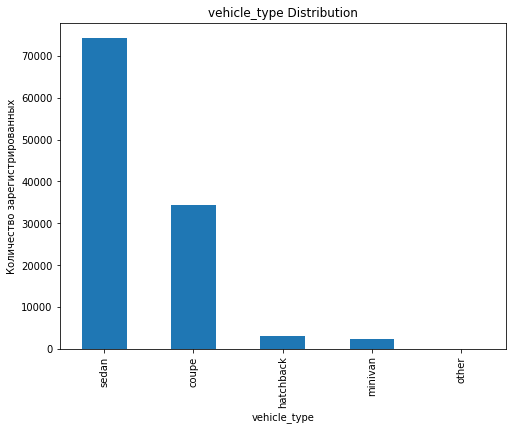

In [48]:
plt.figure(figsize=(8, 6))
data['vehicle_type'].value_counts().plot(kind='bar')
plt.title('vehicle_type Distribution')
plt.xlabel('vehicle_type')
plt.ylabel('Количество зарегистрированных')
plt.show()

Наибольшее количество автомобилей с кузовом sedan

Рассмотрим значения в колонке 'vehicle_transmission' (Тип КПП)

In [49]:
data['vehicle_transmission'].unique()

array(['manual', 'auto', None], dtype=object)

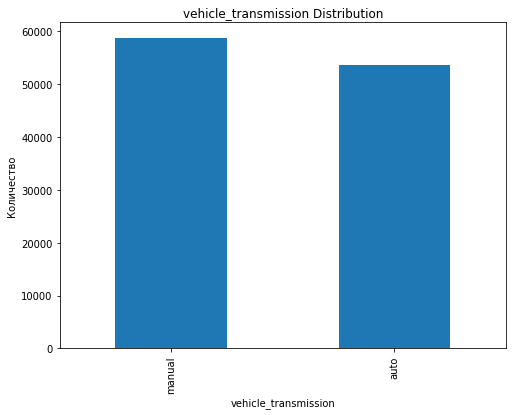

In [50]:
plt.figure(figsize=(8, 6))
data['vehicle_transmission'].value_counts().plot(kind='bar')
plt.title('vehicle_transmission Distribution')
plt.xlabel('vehicle_transmission')
plt.ylabel('Количество')
plt.show()

Примерно одинаковое количество автомобилей с автоматической и ручной коробкой передач

Рассмотрим значения в колонке 'weather' (Погода)

In [51]:
data['weather'].unique()

array(['clear', 'fog', 'cloudy', 'raining', 'snowing', 'other', 'wind'],
      dtype=object)

A — Clear (Ясно)  
B — Cloudy (Облачно)  
C — Raining (Дождь)  
D — Snowing (Снегопад)  
E — Fog (Туман)  
F — Other (Другое)  
G — Wind (Ветер)  
— Not Stated (Не указано)  

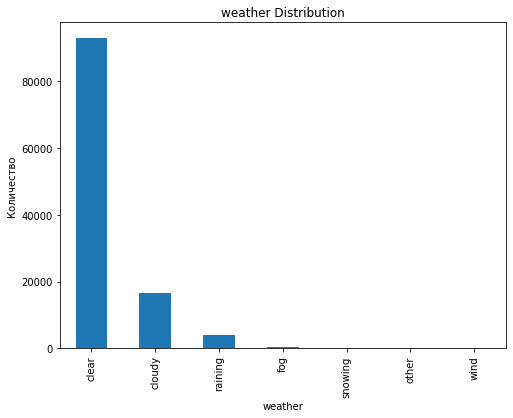

In [52]:
plt.figure(figsize=(8, 6))
data['weather'].value_counts().plot(kind='bar')
plt.title('weather Distribution')
plt.xlabel('weather')
plt.ylabel('Количество')
plt.show()

В большинстве случаев ДТП погода была ясной

Рассмотрим значения в колонке 'location_type' (Тип дороги)

In [53]:
data['location_type'].unique()

array([None, 'highway', 'ramp', 'intersection'], dtype=object)

H — Highway (Шоссе)  
I — Intersection (Перекрёсток)  
R — Ramp (or Collector) (Рампа)  
- or blank — Not State Highway (Не указано)  

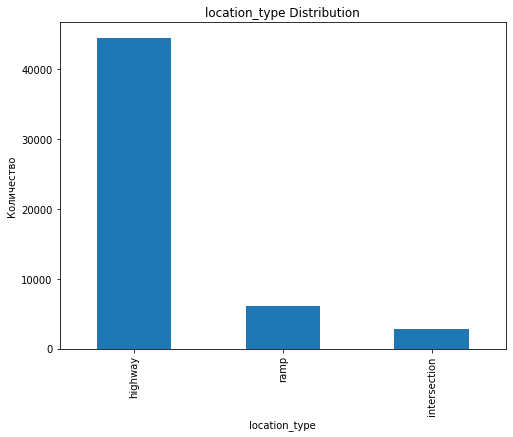

In [54]:
plt.figure(figsize=(8, 6))
data['location_type'].value_counts().plot(kind='bar')
plt.title('location_type Distribution')
plt.xlabel('location_type')
plt.ylabel('Количество')
plt.show()

В большинстве случаев ДТП происходили на шоссе

Рассмотрим значения в колонке road_surface (Состояние дороги)

In [55]:
data['road_surface'].unique()

array(['dry', 'wet', 'snowy', 'slippery'], dtype=object)

A — Dry (Сухая)  
B — Wet (Мокрая)  
C — Snowy or Icy (Заснеженная или обледенелая)  
D — Slippery (Muddy, Oily, etc.) (Скользкая, грязная, маслянистая и т. д.)  
— Not Stated (Не указано)  

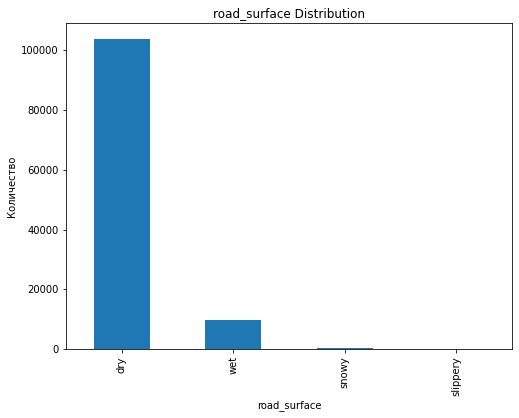

In [56]:
plt.figure(figsize=(8, 6))
data['road_surface'].value_counts().plot(kind='bar')
plt.title('road_surface Distribution')
plt.xlabel('road_surface')
plt.ylabel('Количество')
plt.show()

В большинстве случаев ДТП дорога была сухая

Рассмотрим значения в колонке road_condition (Дорожное состояние)

In [57]:
data['road_condition'].unique()

array(['normal', 'loose material', 'obstruction', 'construction', 'other',
       'reduced width', 'flooded', 'holes'], dtype=object)

A — Holes, Deep Ruts (Ямы, глубокая колея)  
B — Loose Material on Roadway (Сыпучий материал на проезжей части)  
C — Obstruction on Roadway (Препятствие на проезжей части)  
D — Construction or Repair Zone (Зона строительства или ремонта)  
E — Reduced Roadway Width (Уменьшенная ширина проезжей части)  
F — Flooded (Затоплено)  
G — Other (Другое)  
H — No Unusual Condition (Нет ничего необычного)  
- — Not Stated (Не указано)  

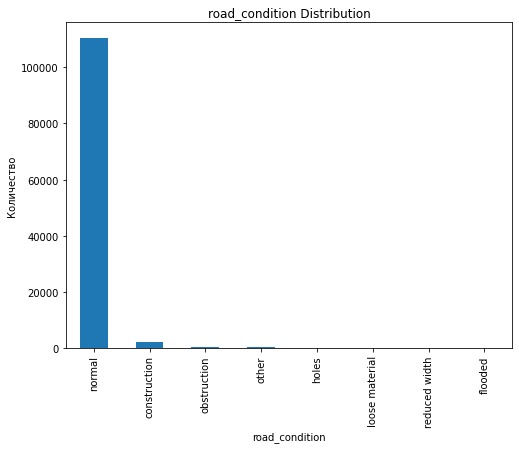

In [58]:
plt.figure(figsize=(8, 6))
data['road_condition'].value_counts().plot(kind='bar')
plt.title('road_condition Distribution')
plt.xlabel('road_condition')
plt.ylabel('Количество')
plt.show()

Наименованя в колонках немного отличаются от описания, предложенного к базе данных, но суть остается той же.
В большинстве случаев ДТП происходило на неповрежденных дорогах (normal / H — No Unusual Condition)

Рассмотрим значения в колонке lighting (освещение)

In [59]:
data['lighting'].unique()

array(['dark with street lights', 'daylight',
       'dark with no street lights', 'dusk or dawn',
       'dark with street lights not functioning'], dtype=object)

A — Daylight (Дневной свет)  
B — Dusk-Dawn (Сумерки-Рассвет)  
C — Dark-Street Lights (Темно-Уличные фонари)  
D — Dark-No Street Lights (Темно-Нет уличных фонарей)  
E — Dark-Street Lights Not Functioning (Темно-Уличные фонари не работают)  
— Not Stated (Не указано)  

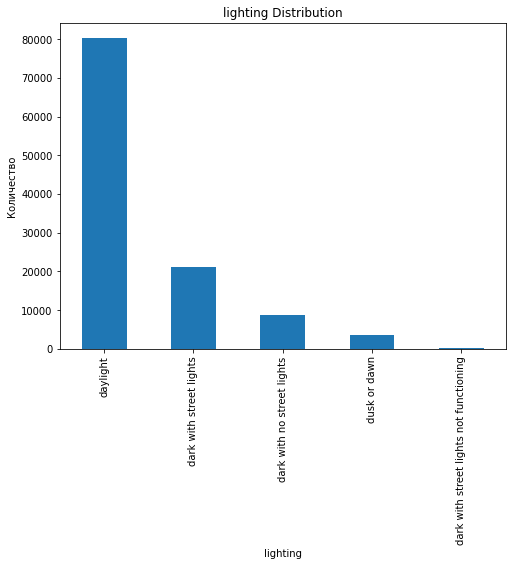

In [60]:
plt.figure(figsize=(8, 6))
data['lighting'].value_counts().plot(kind='bar')
plt.title('lighting Distribution')
plt.xlabel('lighting')
plt.ylabel('Количество')
plt.show()

В большинстве случаев ДТП происходило в дневное время при нормальном освещении (это совпадает с данными из колонки hour - чаще всего дорожные происшествия случались с 15 до 17:00)

Рассмотрим значения в колонке control_device (Устройство управления). В описании к базе данных этот признак указан как CONTROL_CONDITION)

In [61]:
data['control_device'].unique()

array(['none', 'functioning', 'not functioning', 'obscured'], dtype=object)

A — Functioning (Функционирует)  
B — Not Functioning (Не функционирует)  
C — Obscured (Затемнённый)  
D — None (Нет)  

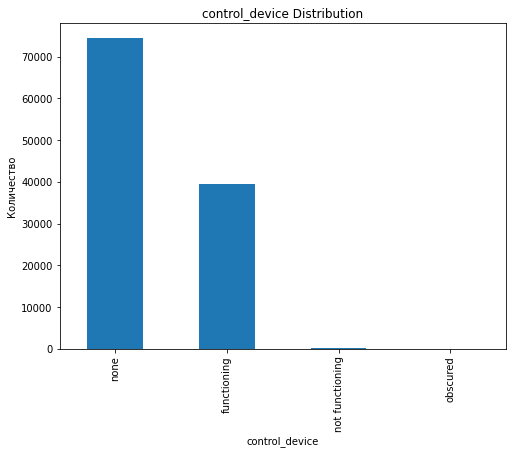

In [62]:
plt.figure(figsize=(8, 6))
data['control_device'].value_counts().plot(kind='bar')
plt.title('control_device Distribution')
plt.xlabel('control_device')
plt.ylabel('Количество')
plt.show()

В большинстве случаев ДТП устройства управления в автомобиле не было.

Рассмотрим значения в колонке direction (Направление движения)

In [63]:
data['direction'].unique()

array(['south', None, 'east', 'north', 'west'], dtype=object)

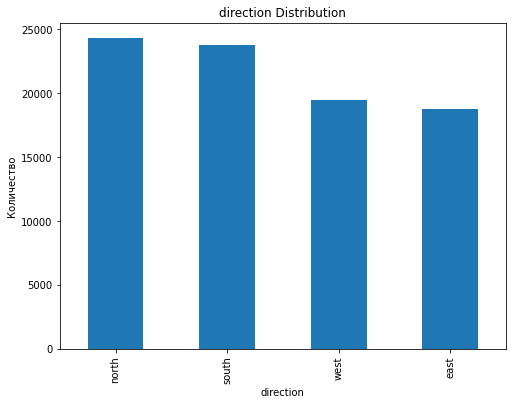

In [64]:
plt.figure(figsize=(8, 6))
data['direction'].value_counts().plot(kind='bar')
plt.title('direction Distribution')
plt.xlabel('direction')
plt.ylabel('Количество')
plt.show()

В большинстве случаев ДТП автомобили направлялись в сторону севера или юга

Заменим пропуски в колонках 'location_type', 'direction', 'vehicle_transmission' на заглушку 'unknown', так как пропущенных данных довольно много, удалять их не стоит, а восстановить мы их не можем.

In [65]:
columns = ['location_type', 'direction', 'vehicle_transmission']

data[columns] = data[columns].fillna('unknown')

In [66]:
# Проверим наличие пропущенных значений
data.isna().sum()

at_fault                0
cellphone_in_use        0
insurance_premium       0
party_sobriety          0
party_drug_physical     0
month                   0
hour                    0
control_device          0
county_city_location    0
lighting                0
location_type           0
road_condition          0
road_surface            0
vehicle_age             0
vehicle_transmission    0
vehicle_type            0
weather                 0
direction               0
distance                0
dtype: int64

In [67]:
# Проверим еще раз наличие дублей
data.duplicated().sum()

44

In [68]:
# Удалим явные дубли
data = data.drop_duplicates()

In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 114099 entries, 0 to 116214
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   at_fault              114099 non-null  int64  
 1   cellphone_in_use      114099 non-null  float64
 2   insurance_premium     114099 non-null  float64
 3   party_sobriety        114099 non-null  object 
 4   party_drug_physical   114099 non-null  object 
 5   month                 114099 non-null  int64  
 6   hour                  114099 non-null  float64
 7   control_device        114099 non-null  object 
 8   county_city_location  114099 non-null  object 
 9   lighting              114099 non-null  object 
 10  location_type         114099 non-null  object 
 11  road_condition        114099 non-null  object 
 12  road_surface          114099 non-null  object 
 13  vehicle_age           114099 non-null  float64
 14  vehicle_transmission  114099 non-null  object 
 15  

Таким образом, после обработки значений и удаления дублей, у нас осталось 19 колонок и 114099 строк

Преобразуем тип данных в некоторых колонках

In [70]:
columns_to_convert = ['insurance_premium', 'cellphone_in_use', 'vehicle_age', 'hour', 'county_city_location', 
                      'distance']

data[columns_to_convert] = data[columns_to_convert].astype(int)

Проверим корреляцию данных

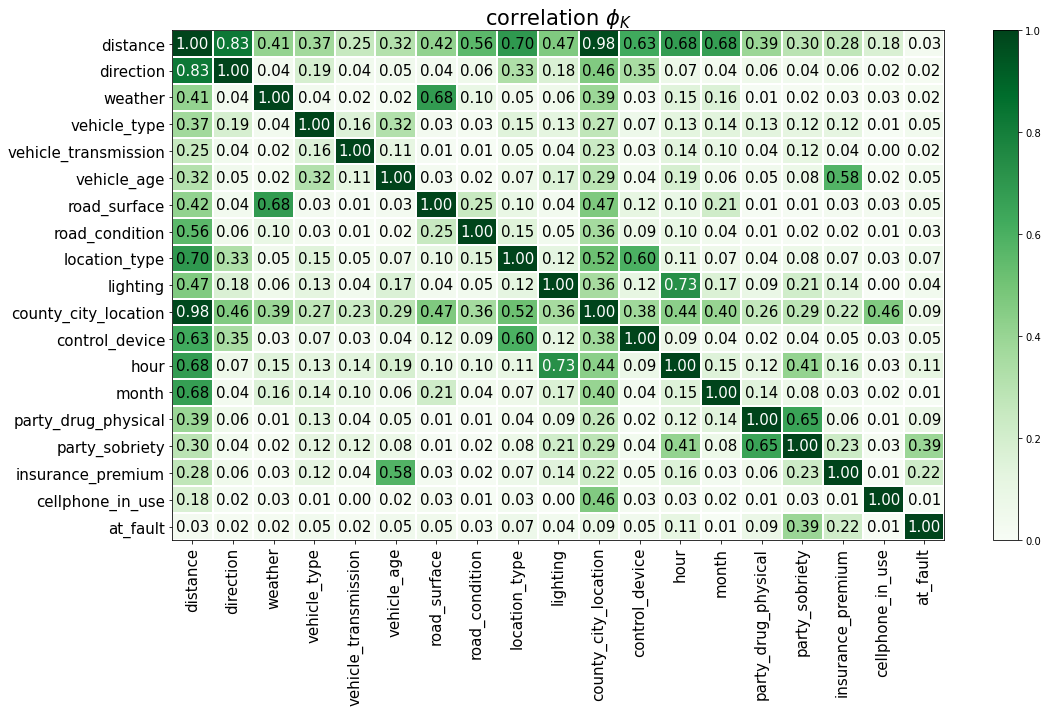

In [62]:
interval_cols = ['vehicle_age', 'insurance_premium']

phik_overview = data.phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(phik_overview.values,
                        x_labels=phik_overview.columns,
                        y_labels=phik_overview.index,
                        vmin=0, vmax=1, color_map="Greens",
                        title=r"correlation $\phi_K$",
                        fontsize_factor=1.5,
                        figsize=(16, 10))
plt.tight_layout();

Обнаружена корреляция между 

* distance - county_city_location 0.98
* distance - direction 0.83
* lighting - hour 0.73
* party_drug_physical - party_sobriety 0.71
* distance - location_type 0.70

Оставим все признаки без изменений.
Хотя некоторые модели (Logistic Regression) могут быть чувствительны к мультиколлинеарности, большинство (такие как RandomForestClassifier, CatBoostClassifier и LGBMClassifier) обычно менее чувствительны к мультиколлинеарности из-за своей способности автоматически обрабатывать нелинейные взаимосвязи и категориальные признаки. К тому же признаки могут оказаться важными для моделирования взаимосвязей в данных, а удаление может привести к потере информации.

### 4.4 Подготовка обучающей и тестовой выборки

In [71]:
# Разделим данные на признаки и целевую переменную
X = data.drop(['at_fault'], axis=1)
y = data['at_fault']

# Разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(91279, 18) (22820, 18) (91279,) (22820,)


Распределим значения по категориальным и числовым признакам для дальнейшей обработки

In [72]:
categorical_cols = X.select_dtypes(include='object').columns
categorical_cols

Index(['party_sobriety', 'party_drug_physical', 'control_device', 'lighting',
       'location_type', 'road_condition', 'road_surface',
       'vehicle_transmission', 'vehicle_type', 'weather', 'direction'],
      dtype='object')

In [73]:
numerical_cols = X.select_dtypes(exclude='object').columns
numerical_cols

Index(['cellphone_in_use', 'insurance_premium', 'month', 'hour',
       'county_city_location', 'vehicle_age', 'distance'],
      dtype='object')

### 5.5 Вывод

На данном этапе исследования 

* Изучены факторы и отобраны те, которые могут влиять на вероятность ДТП
* Подготовлен набор данных на основе первичного предположения заказчика:
    * тип виновника — только машина (car).
    * случаи, когда ДТП привело к любым значимым повреждениям автомобиля любого из участников — все, кроме типа SCRATCH (царапина).
    * данные только за 2012 год.
* Сформирован датасет data, проведена предобработка данных и исследовательский анализ данных:
    * данные проверены и очищены от дубликатов, аномалий, пропущенных значений, проверены и скорректированы типы данных;
    * данные проверены на мультиколлинеарность

* Итоговые данные разделены на обучающую и тестовую выборки

## 5. Обучение моделей

Предстоит решить задачу **классификации**.   

Для оценки качества моделей предлагается выбрать метрику **F1-мера** - это метрика, которая объединяет точность (precision) и полноту (recall) в одну числовую оценку.  

Для решения задачи выберем и обучим на тренировочной выборке несколько моделей машинного обучения:

* LogisticRegression
* RandomForestClassifier
* CatBoostClassifier
* LGBMClassifier

### 5.1 LogisticRegression

In [67]:
# категориальные признаки обработаем OneHotEncoder
cat_pipeline = make_pipeline(
    OneHotEncoder(drop='first')
)

# числовые признаки обработаем StandardScaler
num_pipeline = make_pipeline(
    StandardScaler()
)

# Строим ColumnTransformer
col_transf = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, numerical_cols),
    ('cat_pipeline', cat_pipeline, categorical_cols)
    ],
    n_jobs=-1)

# Строим Pipeline для модели LogisticRegression
pipeline_lr = Pipeline(
    steps=[
    ('col_transf', col_transf),
    ('model_lr', LogisticRegression())
]
    )

In [68]:
# Параметры LogisticRegression для поиска по сетке
param_lr = {
    'model_lr__penalty': ['l2'],  # Тип регуляризации
    'model_lr__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Параметр регуляризации
    'model_lr__fit_intercept': [True, False],  # Интерсепт
}

# Поиск по сетке. В качестве оценки используем метрику f1
grid_lr = GridSearchCV(pipeline_lr, param_grid=param_lr, cv=5, 
                       scoring='f1')

# Обучаем модель
grid_lr.fit(X_train, y_train)

# Получаем лучшие параметры и оценку
best_params_lr = grid_lr.best_params_
score_lr = grid_lr.best_score_

print(f'\nЛучшие параметры LogisticRegression: {best_params_lr}')
print(f'Лучшая оценка F1-меры: {score_lr}')


Лучшие параметры LogisticRegression: {'model_lr__C': 0.001, 'model_lr__fit_intercept': False, 'model_lr__penalty': 'l2'}
Лучшая оценка F1-меры: 0.4739381803267967


###  5.2 RandomForestClassifier

In [74]:
# категориальные признаки обработаем OrdinalEncoder
cat_pipeline = make_pipeline(
    OrdinalEncoder()
)

# числовые данные обработаем StandardScaler
num_pipeline = make_pipeline(
    StandardScaler()
)

col_transf = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, numerical_cols),
    ('cat_pipeline', cat_pipeline, categorical_cols)
], n_jobs=-1)

pipeline_fr = Pipeline(
    steps=[
        ('col_transf', col_transf),
        ('model_fr', RandomForestClassifier())
    ]
)

In [75]:
param_fr = {'model_fr__n_estimators': [10, 50],
            'model_fr__max_depth': [None, 3, 5],
            'model_fr__min_samples_leaf': [1, 2, 4],
            'model_fr__random_state': [42]}

grid_fr = GridSearchCV(pipeline_fr, param_grid=param_fr, cv=5, 
                       scoring='f1')

grid_fr.fit(X_train, y_train)

best_params_fr = grid_fr.best_params_
score_fr = grid_fr.best_score_

print(f'\nЛучшие параметры RandomForestClassifier: {best_params_fr}')
print(f'Лучшая оценка F1-меры: {score_fr}')


Лучшие параметры RandomForestClassifier: {'model_fr__max_depth': None, 'model_fr__min_samples_leaf': 2, 'model_fr__n_estimators': 50, 'model_fr__random_state': 42}
Лучшая оценка F1-меры: 0.5737140745056042


###  5.3 CatBoostClassifier

In [71]:
# Получим индексы категориальных признаков
categorical_cols_idx = [X_train.columns.get_loc(col) for col in categorical_cols]

# Создадим модель CatBoostClassifier с указанием индексов категориальных признаков
catboost_model = CatBoostClassifier(cat_features=categorical_cols_idx)

In [72]:
param_catboost = {
    'learning_rate': [0.01, 0.1, 0.3],
    'depth': [4, 6, 8, 10],
    'iterations': [50, 100],
    'l2_leaf_reg': [1, 3, 5],
    'random_state': [42]
}

grid_catboost = GridSearchCV(catboost_model, param_grid=param_catboost, cv=5, 
                       scoring='f1')

grid_catboost.fit(X_train, y_train)

best_params_catboost = grid_catboost.best_params_
score_catboost = grid_catboost.best_score_

print(f'\nЛучшие параметры CatBoostClassifier: {best_params_catboost}')
print(f'Лучшая оценка F1-меры: {score_catboost}')

0:	learn: 0.6921418	total: 97.1ms	remaining: 4.76s
1:	learn: 0.6911613	total: 127ms	remaining: 3.05s
2:	learn: 0.6901602	total: 167ms	remaining: 2.62s
3:	learn: 0.6892079	total: 207ms	remaining: 2.38s
4:	learn: 0.6882525	total: 237ms	remaining: 2.13s
5:	learn: 0.6873580	total: 266ms	remaining: 1.95s
6:	learn: 0.6864459	total: 296ms	remaining: 1.81s
7:	learn: 0.6855786	total: 326ms	remaining: 1.71s
8:	learn: 0.6847139	total: 356ms	remaining: 1.62s
9:	learn: 0.6838362	total: 386ms	remaining: 1.54s
10:	learn: 0.6829920	total: 420ms	remaining: 1.49s
11:	learn: 0.6821584	total: 449ms	remaining: 1.42s
12:	learn: 0.6813508	total: 479ms	remaining: 1.36s
13:	learn: 0.6805558	total: 509ms	remaining: 1.31s
14:	learn: 0.6797582	total: 539ms	remaining: 1.26s
15:	learn: 0.6789974	total: 569ms	remaining: 1.21s
16:	learn: 0.6782532	total: 608ms	remaining: 1.18s
17:	learn: 0.6774924	total: 642ms	remaining: 1.14s
18:	learn: 0.6767725	total: 671ms	remaining: 1.09s
19:	learn: 0.6760685	total: 701ms	remain

###  5.4 LGBMClassifier

In [73]:
cat_pipeline = make_pipeline(
    OrdinalEncoder()
)

num_pipeline = make_pipeline(
    StandardScaler()
)

col_transf = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, numerical_cols),
    ('cat_pipeline', cat_pipeline, categorical_cols)
], n_jobs=-1)

pipeline_lgbm = Pipeline(
    steps=[
        ('col_transf', col_transf),
        ('model_lgbm', LGBMClassifier())
    ]
)

In [74]:
param_lgbm = {
    'model_lgbm__learning_rate': [0.1, 0.3],
    'model_lgbm__max_depth': [4, 6, 8],
    'model_lgbm__n_estimators': [10, 20],
    'model_lgbm__reg_alpha': [0.1, 1.0],
    'model_lgbm__reg_lambda': [0.1, 1.0],
    'model_lgbm__num_leaves': [10, 20],
    'model_lgbm__random_state': [42]
}

grid_lgbm = GridSearchCV(pipeline_lgbm, param_grid=param_lgbm, cv=5, 
                       scoring='f1')

grid_lgbm.fit(X_train, y_train)

best_params_lgbm = grid_lgbm.best_params_
score_lgbm = grid_lgbm.best_score_

print(f'\nЛучшие параметры LGBMClassifier: {best_params_lgbm}')
print(f'Лучшая оценка F1-меры: {score_lgbm}')


Лучшие параметры LGBMClassifier: {'model_lgbm__learning_rate': 0.3, 'model_lgbm__max_depth': 8, 'model_lgbm__n_estimators': 20, 'model_lgbm__num_leaves': 20, 'model_lgbm__random_state': 42, 'model_lgbm__reg_alpha': 1.0, 'model_lgbm__reg_lambda': 1.0}
Лучшая оценка F1-меры: 0.5596584307756666


### 5.5 Анализ результатов

Зафиксируем полученные результаты в таблице

| Модель                  | F1-мера |
|-------------------------|---------|
| LogisticRegression      | 0.4739  |
| RandomForestClassifier  | 0.5737  |
| CatBoostClassifier      | 0.5726  |
| LGBMClassifier          | 0.5597  |


В результате обучения нескольких моделей на тренировочной выборке, лучший результат показала модель RandomForestClassifier c f1-мерой 0.5737 и гиперпараметрами:   
max_depth: None   
min_samples_leaf: 2  
n_estimators: 50  

### 5.6 Вывод

Для решения задачи классификации были выбраны и обучены на тренировочной выборке несколько моделей машинного обучения:

LogisticRegression
RandomForestClassifier
CatBoostClassifier
LGBMClassifier

Для оценки качества моделей была выбрана метрика F1-мера, которая объединяет точность (precision) и полноту (recall) в одну числовую оценку.

В результате обучения лучший результат показала модель **RandomForestClassifier** c **f1-мерой 0.5737**.
Эту модель возьмем для обучения и предсказания на тестовой выборке.

## 6. Проведите анализ важности факторов ДТП

### 6.1 Обучение лучшей модели и предсказание на тестовой выборке

In [76]:
# Обучим модель с лучшими гиперпараметрами
best_fr_model = grid_fr.best_estimator_

# Предскажем на тестовой выборке
y_pred = best_fr_model.predict(X_test)

# Расчет F1-меры, Recall (Полноты) и Precision (Точности)
f1_fr = f1_score(y_test, y_pred)
precision_fr = precision_score(y_test, y_pred)
recall_fr = recall_score(y_test, y_pred, average='binary')

print(f'F1 на тестовой выборке: {f1_fr}')
print(f'precision на тестовой выборке: {precision_fr}')
print(f'recall на тестовой выборке: {recall_fr}')

F1 на тестовой выборке: 0.571813750907394
precision на тестовой выборке: 0.648477008114783
recall на тестовой выборке: 0.5113604748214783


Результат F1-меры на тестовой выборке (0.5718)

### 6.2 Графический анализ «Матрица ошибок»

Проведем графический анализ «Матрица ошибок». Выведем полноту и точность на график.

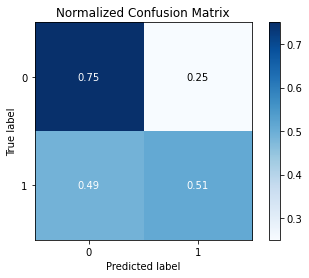

In [77]:
skplt.metrics.plot_confusion_matrix(y_test, y_pred, normalize=True)
plt.show()

Согласно матрице ошибок мы видим, что показатель True Positives (TP) довольно высок, это означает, что наша модель в 75% случаев верно предсказывает невиновность участника, модель ошибается в 24%.

Что касается оценки виновности True Negatives (TN), тут модель только в 51% правильно определяет виновность участника, в 49% случаев ошибается.

Построим визуализацию Recall (Полноты) и Precision (Точности) нашей модели

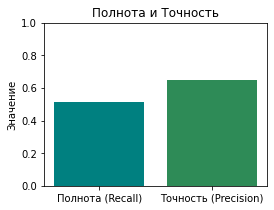

In [78]:
# визуализация Recall и Precision
plt.figure(figsize=(4, 3))
plt.bar(['Полнота (Recall)', 'Точность (Precision)'], [recall_fr, precision_fr], color=['teal', 'seagreen'])
plt.ylim(0, 1)
plt.ylabel('Значение')
plt.title('Полнота и Точность')
plt.show()

* Метрика **Precision (Точность)** показывает, какая доля объектов, классифицированных как положительные моделью, действительно является положительными. Precision на тестовой выборке равна 0.6485, что означает, что примерно 66% объектов, предсказанных как виновные в ДТП, действительно являются виновными.

* Метрика **Recall (Полнота)** показывает, какая доля положительных объектов была успешно обнаружена моделью. Recall на тестовой выборке равен 0.5114, что означает, что модель обнаружила около 52% всех реальных виновных в ДТП.

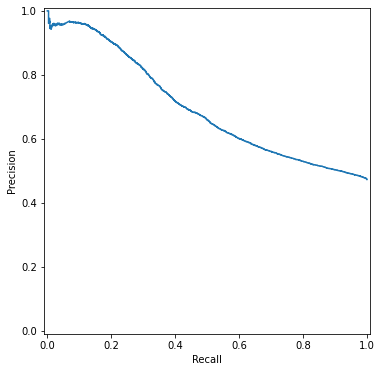

In [92]:
# Получим вероятность класса 1
probs = best_fr_model.predict_proba(X_test)[:, 1]

# Вычислим precision и recall
precision, recall, _ = precision_recall_curve(y_test, probs)

# Построим кривую precision-recall
pr_display = PrecisionRecallDisplay(precision=precision, recall=recall).plot()
plt.gcf().set_size_inches(8, 6)
plt.show()

Линия спускается по мере увеличения recall, что указывает на то, что часть положительных объектов класса 1 была правильно определена, но вместе с тем уменьшается точность (precision). Это означает, что при увеличении recall модель делает больше ошибок и классифицирует некоторые негативные объекты как положительные.

Когда recall достигает 1 (все положительные объекты были правильно определены), precision уменьшается до 0.5, что означает, что среди всех объектов, которые модель предсказала как положительные, только половина действительно принадлежит к классу 1.

### 6.3 Анализ важности основных факторов, влияющих на вероятность ДТП.

Проанализируем важность основных факторов, влияющих на вероятность ДТП.

Top 10 важных признаков:
                 Feature  Importance
1      insurance_premium    0.185931
4                  month    0.147004
6         control_device    0.121534
3    party_drug_physical    0.101970
7   county_city_location    0.101330
5                   hour    0.080136
2         party_sobriety    0.072376
17              distance    0.047367
14          vehicle_type    0.024735
15               weather    0.020883


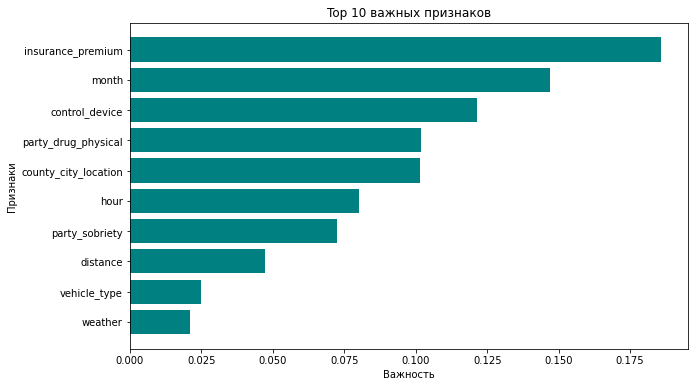

In [78]:
# Получим модель RandomForestClassifier
rf_model = best_fr_model.named_steps['model_fr']

# Получим важность признаков для лучшей модели RandomForestClassifier
feature_importance = rf_model.feature_importances_

# Создадим DataFrame для удобного представления результатов
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})

# Отсортируем признаки по важности
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Выведем топ-10 важных признаков
top_n = 10
print(f'Top {top_n} важных признаков:')
print(importance_df.head(top_n))

# График
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:top_n], importance_df['Importance'][:top_n], color='teal')
plt.xlabel('Важность')
plt.ylabel('Признаки')
plt.title('Top 10 важных признаков')
plt.gca().invert_yaxis()
plt.show()

Таким образом, самым важным фактором, влияющим на вероятность ДТП является INSURANCE_PREMIUM (сумма страховки).
Чуть менее важными признаками являются также месяц, устройство управления в автомобиле, состояние водителя (физическое или с учётом принятых лекарств) и трезвость водителя.

### 6.4 График зависимости самого важного фактора и целевой переменной

Для одного из выявленных важных факторов проведите дополнительное исследование:

* Покажите график зависимости фактора и целевой переменной.
* Предложите, чем можно оборудовать автомобиль, чтобы учесть этот фактор во время посадки водителя.

Визуализируем зависимость между основным фактором insurance_premium (суммой страховки) и целевым признаком at_fault (виновность участника) на линейном графике

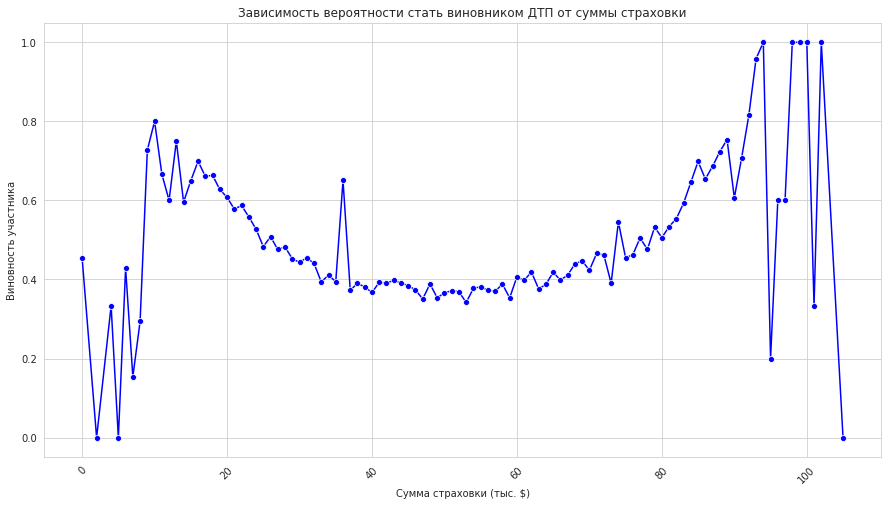

In [62]:
at_fault_mean = data.groupby('insurance_premium')['at_fault'].mean()

# построение графика
sns.set_style("whitegrid")
plt.figure(figsize=(15, 8))
sns.lineplot(x=at_fault_mean.index, y=at_fault_mean.values, marker='o', color='b')
plt.xlabel('Сумма страховки (тыс. $)')
plt.ylabel('Виновность участника')
plt.title('Зависимость вероятности стать виновником ДТП от суммы страховки')
plt.xticks(rotation=45)
plt.show()

На графике видим, что, в большинстве случаев, чем больше сумма страховки, тем выше вероятность виновности участника в ДТП.

Возможно, так происходит, потому что более высокие страховые суммы могут приводить к более безответственному поведению водителей. Они могут чувствовать, что имеют "подушку безопасности" и поэтому меньше беспокоятся о возможных последствиях своих действий на дороге.

Также возможно, что страховые компании устанавливают более высокие страховки для водителей с плохими историями вождения, так как они считают их более рискованными.

С учетом этого анализа, каршеринговый сервис может принять следующие меры:

* Отслеживать поведение водителей с высокими страховыми суммами и предоставлять им обратную связь о возможных улучшениях. Это может помочь им осознать свои слабые места и стать более внимательными на дороге.

* Использовать данные о страховых суммах и предыдущих ДТП, чтобы предложить персонализированные рекомендации водителям. Например, если у водителя высокая страховая сумма и высокая вероятность виновности в ДТП, система может предложить маршруты с меньшим трафиком или менее рискованные дороги.

* Предложить скидки на страховые полисы для водителей, которые проходят курсы безопасного вождения или показывают улучшение в своем водительском стаже.

* Ввести программы поощрения для водителей с низким риском виновности в ДТП. Это может включать в себя скидки на аренду автомобиля или другие бонусы за безаварийное вождение.

* Внедрите в автомобили системы помощи водителю, такие как системы предупреждения о столкновении, системы контроля полосы движения и управления усталостью водителя. Эти технологии могут помочь предотвратить ДТП или снизить их тяжесть.

## Выводы

Лучшая модель **RandomForestClassifier** при обучении и предсказании на тестовой выборке дала следующие результаты:

* F1: 0.5718
* Precision: 0.6485
* Recall: 0.5114

**Precision (Точность)** означает, что примерно 65% объектов, предсказанных как виновные в ДТП, действительно являются виновными.

**Recall (Полнота)** на тестовой выборке равен 0.5114, что означает, что модель обнаружила около 52% всех реальных виновных в ДТП.

Согласно **"матрице ошибок"** мы видим, что показатель True Positives (TP) довольно высок, это означает, что наша модель в 76% случаев верно предсказывает невиновность участника, модель ошибается в 24%.
Что касается оценки виновности True Negatives (TN), тут модель только в 52% правильно определяет виновность участника, в 48% случаев ошибается.

Проанализировав важность основных факторов, влияющих на вероятность ДТП, обнаружили, что самым важными являются:

* INSURANCE_PREMIUM (сумма страховки)
* MONTH (месяц в году)
* CONTROL_DEVICE (устройство управления в автомобиле)
* PARTY_DRUG_PHYSICAL (состояние водителя: физическое или с учётом принятых лекарств)
* PARTY_SOBRIETY (трезвость водителя).

Для самого важного фактора **INSURANCE_PREMIUM (сумма страховки)** провели дополнительное исследование.
Обнаружили, что, в большинстве случаев, чем больше сумма страховки, тем выше вероятность виновности участника в ДТП.

С учетом этого анализа, каршеринговый сервис может принять следующие меры:

* Отслеживать поведение водителей с высокими страховыми суммами и предоставлять им обратную связь о возможных улучшениях. Это может помочь им осознать свои слабые места и стать более внимательными на дороге.

* Использовать данные о страховых суммах и предыдущих ДТП, чтобы предложить персонализированные рекомендации водителям. Например, если у водителя высокая страховая сумма и высокая вероятность виновности в ДТП, система может предложить маршруты с меньшим трафиком или менее рискованные дороги.

* Предложить скидки на страховые полисы для водителей, которые проходят курсы безопасного вождения или показывают улучшение в своем водительском стаже.

* Ввести программы поощрения для водителей с низким риском виновности в ДТП. Это может включать в себя скидки на аренду автомобиля или другие бонусы за безаварийное вождение.

* Внедрите в автомобили системы помощи водителю, такие как системы предупреждения о столкновении, системы контроля полосы движения и управления усталостью водителя. Эти технологии могут помочь предотвратить ДТП или снизить их тяжесть.

Исходя из важности других факторов **(MONTH, CONTROL_DEVICE, PARTY_DRUG_PHYSICAL, PARTY_SOBRIETY)**, влияющих на вероятность ДТП, можно предложить следующие рекомендации каршеринговому сервису:

* Внедрение в автомобили системы мониторинга состояния водителя, которые могут отслеживать физическое состояние и трезвость. Это может включать в себя датчики алкоголя в салоне автомобиля или датчики биометрических данных, таких как сердечный ритм или уровень сахара в крови. При обнаружении признаков опьянения или непригодности к управлению автомобилем, система может предложить водителю альтернативные варианты перемещения или даже заблокировать возможность начать движение.

* Оборудовать автомобили современными устройствами управления, которые могут повысить безопасность и контролируемость водителя. Например, системы адаптивного круиз-контроля, предупреждения о нарушении полосы движения и автоматического торможения могут помочь предотвратить ДТП в случае неправильного или неадекватного поведения водителя.

* Интегрировать в автомобили технологии, которые помогают водителям соблюдать правила дорожного движения. Например, системы предупреждения о превышении скорости или системы контроля полосы движения могут снизить риск ДТП, связанный с неправильным поведением водителей.

* Разработать системы предупреждения и контроля, которые могут автоматически определять рискованные ситуации на дороге и информировать водителя об этом. Например, системы предупреждения о возможной усталости водителя или о длительном отсутствии активности за рулем могут помочь предотвратить возможные аварии.

Такие меры помогут каршеринговому сервису учесть важные факторы, влияющие на вероятность ДТП, и сделать его услугу более безопасной и надежной для всех пользователей.